# Un ratón con el córtex casi entero de células humanas. ¿Camina igual?

Vaciaron el córtex de un ratón antes de nacer de sus neuronas principales y lo rellenaron, el día del nacimiento, con organoides de células humanas. Tres meses después, el 91,9% de ese tejido cortical era humano. Y el ratón corría a la misma velocidad de siempre.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Kaganovsky et al. (2026). *Developmental xenocortication using human-derived organoids in mice*. **Nature**.
DOI: [10.1038/s41586-026-11032-2](https://doi.org/10.1038/s41586-026-11032-2) · Open Access

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-16-xenocortex-organoides-humanos-raton/notebook.ipynb)

**Video:** pendiente

## De qué va esto

Un organoide cortical es una bolita de tejido cerebral humano cultivada en el laboratorio a partir de células madre. Desde hace años se trasplantan en cerebros de rata o ratón para ver cómo maduran las neuronas humanas dentro de un animal vivo. El problema: el cerebro del huésped ya está lleno, y las células humanas quedan arrinconadas compitiendo por espacio y conexiones.

El equipo del laboratorio de Sergiu Pașca (Stanford) probó otra cosa. Con una manipulación genética eliminaron las neuronas excitadoras (glutamatérgicas) del córtex y el hipocampo del ratón antes de nacer — un ratón sin palio, que ellos llaman *apalial*. En ese hueco implantaron, el día del nacimiento, cuatro organoides corticales humanos. Al resultado lo llaman ratón *xenocortical* (XCX). De 29 ratones trasplantados con tres líneas celulares distintas, el injerto prendió en 25 de los 29 ratones — 86,2%.

Lo que tenemos: los *Source Data* del paper — resonancias magnéticas de los injertos, la composición celular por secuenciación de núcleos, tres pruebas de conducta y el tamaño de 1.098 neuronas. Veamos qué dicen.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
AZAR_YMAZE = 50              # % de alternancia esperado por puro azar en el laberinto en Y
FUENTE = 'Fuente: Kaganovsky et al. (2026), Nature | Datos: Source Data del paper (MOESM7)'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_SECUNDARIO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_CORRELACION = '#7C3AED'
COLOR_CONTEXTO = '#BBBBBB'

import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
PAPER = f'{BASE}/papers/2026-09-16-xenocortex-organoides-humanos-raton'

# Estilo CaM (local -> fallback GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Datos (descarga automatica si no estan en local)
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
ARCHIVOS = ['volumen_cerebro_control_vs_apalial.csv', 'crecimiento_injerto_mri.csv',
            'porcentaje_cortex_humano.csv', 'clusters_glun_snrnaseq.csv',
            'catwalk_velocidad.csv', 'catwalk_patas_en_suelo.csv',
            'catwalk_ratio_alterno_cruzado.csv', 'ymaze.csv', 'soma_diametro_ven.csv']
for f in ARCHIVOS:
    if not os.path.exists(f'datos/{f}'):
        urllib.request.urlretrieve(f'{PAPER}/datos/{f}', f'datos/{f}')

vol = pd.read_csv('datos/volumen_cerebro_control_vs_apalial.csv')   # MRI: control vs apalial
cre = pd.read_csv('datos/crecimiento_injerto_mri.csv')              # MRI: injerto 2 vs 3 meses, pareado
hum = pd.read_csv('datos/porcentaje_cortex_humano.csv')             # % cortex humano a 3 meses
clu = pd.read_csv('datos/clusters_glun_snrnaseq.csv')               # snRNA-seq: % nucleos por cluster
vel = pd.read_csv('datos/catwalk_velocidad.csv')                    # CatWalk: velocidad
pat = pd.read_csv('datos/catwalk_patas_en_suelo.csv')               # CatWalk: patrones de apoyo (nivel grupo)
rat = pd.read_csv('datos/catwalk_ratio_alterno_cruzado.csv')        # CatWalk: ratio alterno/cruzado
ym  = pd.read_csv('datos/ymaze.csv')                                # laberinto en Y
som = pd.read_csv('datos/soma_diametro_ven.csv')                    # diametro de soma tipo VEN
GRUPOS = ['Control', 'Apallial', 'XCX']
ETIQ = {'Control': 'Control', 'Apallial': 'Apalial', 'XCX': 'Xenocortical'}
COL_GRUPO = {'Control': COLOR_CONTEXTO, 'Apallial': COLOR_REFERENCIA, 'XCX': COLOR_DATOS}

def es(x, dec=0):
    # formato espanol: 17.612 / 91,9
    s = f'{x:,.{dec}f}'
    return s.replace(',', 'X').replace('.', ',').replace('X', '.')

def sci(p):
    # p-value legible: 0,032 / 1,7×10⁻⁶
    if p >= 0.001:
        return es(p, 3)
    exp = int(np.floor(np.log10(p)))
    mant = p / 10**exp
    sup = str(-exp).translate(str.maketrans('0123456789', '⁰¹²³⁴⁵⁶⁷⁸⁹'))
    return f'{es(mant, 1)}×10⁻{sup}'

def cohen_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / sp

print(f'MRI:      {len(cre)} ratones con injerto medido a 2 y 3 meses; {len(hum)} con % de córtex humano')
print(f'snRNA-seq: {clu.muestra_id.nunique()} muestras × {clu.replica.nunique()} réplicas, {clu.cluster.nunique()} clusters de neuronas excitadoras')
print(f'Conducta: CatWalk n = {vel.groupby("grupo").size().to_dict()} · Y-maze n = {ym.groupby("grupo").size().to_dict()}')

MRI:      14 ratones con injerto medido a 2 y 3 meses; 7 con % de córtex humano
snRNA-seq: 3 muestras × 2 réplicas, 8 clusters de neuronas excitadoras
Conducta: CatWalk n = {'Apallial': 10, 'Control': 16, 'XCX': 7} · Y-maze n = {'Apallial': 16, 'Control': 39, 'XCX': 18}


## Aquí está.

Catorce ratones, una resonancia a los 2 meses y otra a los 3.

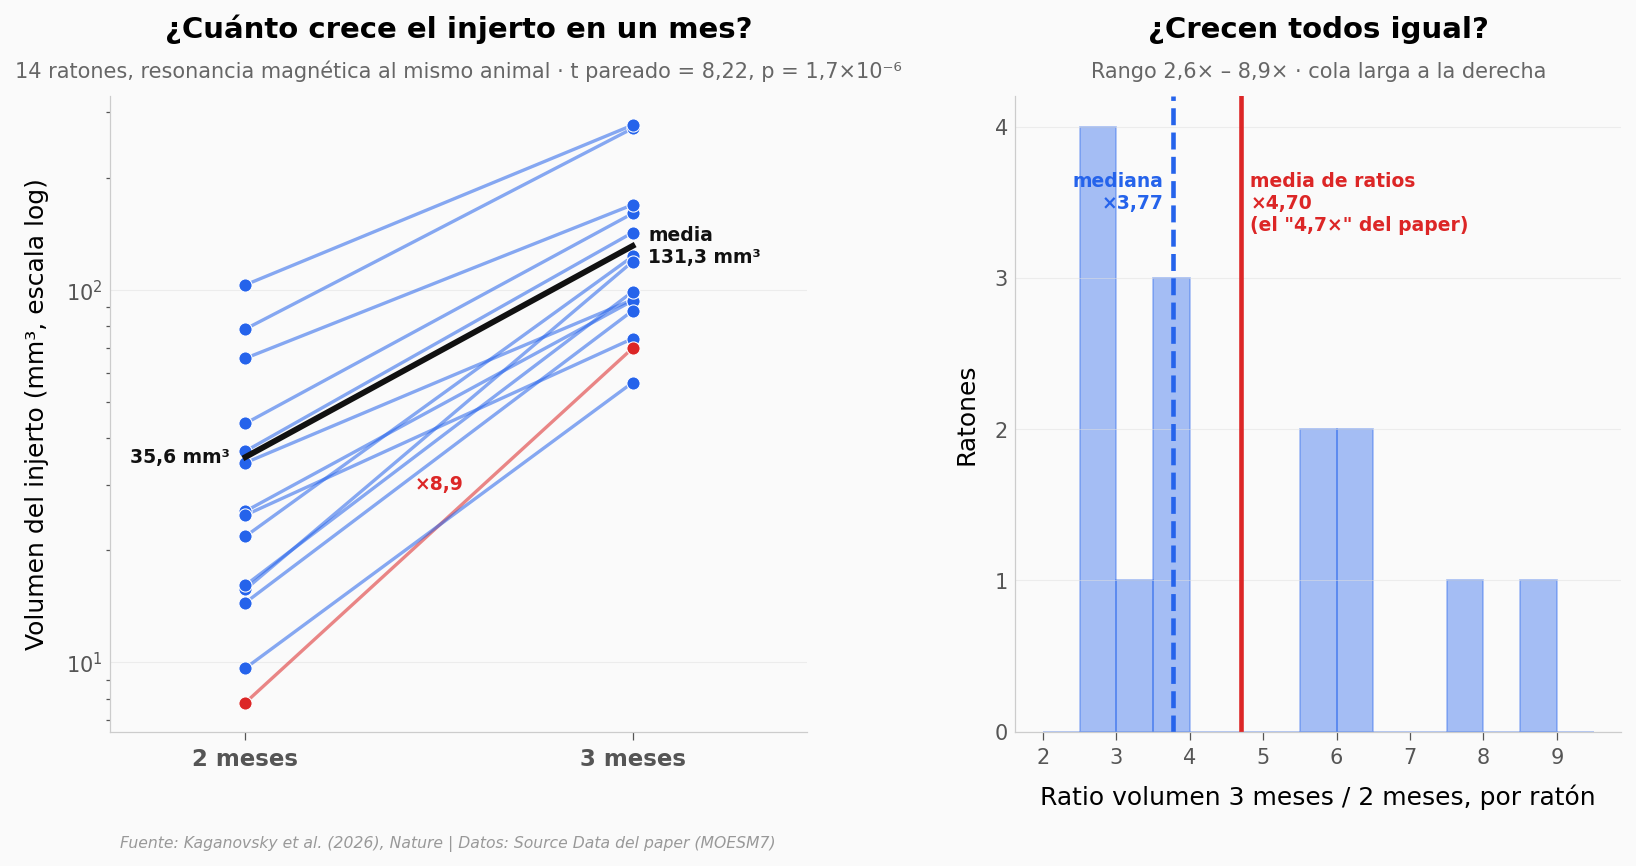

Crecieron 14 de 14 ratones
Media de los ratios por ratón: 4,70×  ·  mediana: 3,77×  ·  ratio de las medias: 3,69×
IQR del ratio: 3,10–6,02×
t pareado = 8,219, p = 1,7×10⁻⁶  ·  d pareado = 2,20  ·  Wilcoxon p = 1,2×10⁻⁴

Córtex de origen humano a 3 meses: 91,9% ± 2,7 (n = 7, rango 88,6–96,2%)
Cerebro apalial vs control (sustancia gris + blanca, MRI): 197,2 vs 412,0 mm³ → 52,1% menos (n = 4 vs 5; Mann-Whitney p = 0,016, d = 13,58)


In [2]:
cre['ratio'] = cre.vol_3_meses_mm3 / cre.vol_2_meses_mm3
n = len(cre)
t_par, p_par = stats.ttest_rel(cre.vol_3_meses_mm3, cre.vol_2_meses_mm3)
dif = cre.vol_3_meses_mm3 - cre.vol_2_meses_mm3
d_par = dif.mean() / dif.std(ddof=1)
w_stat, p_w = stats.wilcoxon(cre.vol_3_meses_mm3, cre.vol_2_meses_mm3)
fold_media_ratios = cre.ratio.mean()
fold_mediana = cre.ratio.median()
fold_de_medias = cre.vol_3_meses_mm3.mean() / cre.vol_2_meses_mm3.mean()

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1.15, 1]})

# Izquierda: slope chart pareado (log)
for _, r in cre.iterrows():
    c = COLOR_ALERTA if r.ratio == cre.ratio.max() else COLOR_DATOS
    ax.plot([0, 1], [r.vol_2_meses_mm3, r.vol_3_meses_mm3], color=c, alpha=0.55, linewidth=1.6, zorder=3)
    ax.scatter([0, 1], [r.vol_2_meses_mm3, r.vol_3_meses_mm3], color=c, s=40, edgecolors='white',
               linewidths=0.5, zorder=5)
ax.plot([0, 1], [cre.vol_2_meses_mm3.mean(), cre.vol_3_meses_mm3.mean()], color='#111111',
        linewidth=2.8, zorder=6)
ax.text(1.04, cre.vol_3_meses_mm3.mean(), f'media\n{es(cre.vol_3_meses_mm3.mean(), 1)} mm³',
        fontsize=9, fontweight='bold', color='#111111', va='center')
ax.text(-0.04, cre.vol_2_meses_mm3.mean(), f'{es(cre.vol_2_meses_mm3.mean(), 1)} mm³',
        fontsize=9, fontweight='bold', color='#111111', va='center', ha='right')
imax = cre.ratio.idxmax()
ax.text(0.5, np.sqrt(cre.loc[imax, 'vol_2_meses_mm3'] * cre.loc[imax, 'vol_3_meses_mm3']) * 1.25,
        f'×{es(cre.ratio.max(), 1)}', fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='center')
ax.set_yscale('log')
ax.set_xlim(-0.35, 1.45)
ax.set_xticks([0, 1]); ax.set_xticklabels(['2 meses', '3 meses'], fontsize=11, fontweight='bold')
ax.set_ylabel('Volumen del injerto (mm³, escala log)')
ax.set_title('¿Cuánto crece el injerto en un mes?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{n} ratones, resonancia magnética al mismo animal · t pareado = {es(t_par, 2)}, p = {sci(p_par)}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Derecha: distribucion de los ratios por raton
ax2.hist(cre.ratio, bins=np.arange(2, 10, 0.5), color=COLOR_DATOS, alpha=0.4, edgecolor=COLOR_DATOS, linewidth=0.8)
ax2.axvline(fold_media_ratios, color=COLOR_ALERTA, linewidth=2.2)
ax2.axvline(fold_mediana, color=COLOR_DATOS, linewidth=2.2, linestyle='--')
ax2.text(fold_media_ratios + 0.12, 3.7, f'media de ratios\n×{es(fold_media_ratios, 2)}\n(el "4,7×" del paper)',
         fontsize=9, color=COLOR_ALERTA, fontweight='bold', va='top')
ax2.text(fold_mediana - 0.12, 3.7, f'mediana\n×{es(fold_mediana, 2)}', fontsize=9, color=COLOR_DATOS,
         fontweight='bold', va='top', ha='right')
ax2.set_ylim(0, 4.2)
ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.set_xlabel('Ratio volumen 3 meses / 2 meses, por ratón')
ax2.set_ylabel('Ratones')
ax2.set_title('¿Crecen todos igual?', fontsize=14, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, f'Rango {es(cre.ratio.min(), 1)}× – {es(cre.ratio.max(), 1)}× · cola larga a la derecha',
         transform=ax2.transAxes, fontsize=10, color='#666666', ha='center')
fig.subplots_adjust(wspace=0.32)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/crecimiento_injerto.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Crecieron {int((cre.ratio > 1).sum())} de {n} ratones')
print(f'Media de los ratios por ratón: {es(fold_media_ratios, 2)}×  ·  mediana: {es(fold_mediana, 2)}×  ·  ratio de las medias: {es(fold_de_medias, 2)}×')
print(f'IQR del ratio: {es(cre.ratio.quantile(0.25), 2)}–{es(cre.ratio.quantile(0.75), 2)}×')
print(f't pareado = {es(t_par, 3)}, p = {sci(p_par)}  ·  d pareado = {es(d_par, 2)}  ·  Wilcoxon p = {sci(p_w)}')

# Cuanto del cortex es humano a los 3 meses, y cuanto encogio el cerebro apalial
ctrl_v = vol[vol.grupo == 'Control'].volumen_mm3
apa_v = vol[vol.grupo == 'Apallial'].volumen_mm3
u, p_u = stats.mannwhitneyu(ctrl_v, apa_v, alternative='two-sided')
print(f'\nCórtex de origen humano a 3 meses: {es(hum.pct_cortex_humano.mean(), 1)}% ± {es(hum.pct_cortex_humano.std(ddof=1), 1)} (n = {len(hum)}, rango {es(hum.pct_cortex_humano.min(), 1)}–{es(hum.pct_cortex_humano.max(), 1)}%)')
print(f'Cerebro apalial vs control (sustancia gris + blanca, MRI): {es(apa_v.mean(), 1)} vs {es(ctrl_v.mean(), 1)} mm³ '
      f'→ {es(100*(1 - apa_v.mean()/ctrl_v.mean()), 1)}% menos (n = {len(apa_v)} vs {len(ctrl_v)}; Mann-Whitney p = {sci(p_u)}, d = {es(cohen_d(ctrl_v, apa_v), 2)})')

Los 14 ratones crecieron, sin excepción, y la prueba pareada lo confirma con holgura: el injerto creció 4,7× entre los 2 y los 3 meses (media de los ratios por ratón, n = 14), con un tamaño de efecto pareado enorme (d = 2,20). Pero la gráfica de la derecha cuenta algo que el "4,7×" esconde: la mediana del ratio por ratón es 3,77×, y unos pocos ratones que multiplicaron su injerto por 6, 7 y hasta 9 tiran de la media hacia arriba. Dicho de otro modo, el ratón típico creció menos de 4 veces. Los dos números son correctos; hay que saber cuál se está citando.

El punto de partida también importa: el cerebro apalial tiene un 52,1% menos de volumen que el control antes del trasplante, porque le faltan las neuronas excitadoras de todo el córtex y el hipocampo. Ese es el hueco que el injerto rellena. Y lo rellena de verdad: a los 3 meses, el 91,9% del tejido cortical es de origen humano (n = 7).

## ¿De qué está hecho?

Volumen no es lo mismo que córtex. Para saber qué tipo de neuronas produjo el injerto, el equipo secuenció el ARN de núcleos individuales (snRNA-seq) de tres injertos, dos líneas celulares, con dos réplicas técnicas cada uno, y clasificó cada núcleo por el tipo de neurona excitadora al que se parece. El abstract destaca una en particular: las neuronas de proyección de capa 5 extratelencefálicas (L5-ET), las que en un cerebro real mandan axones fuera del córtex, hacia el tronco y la médula. Veamos cuánto pesan.

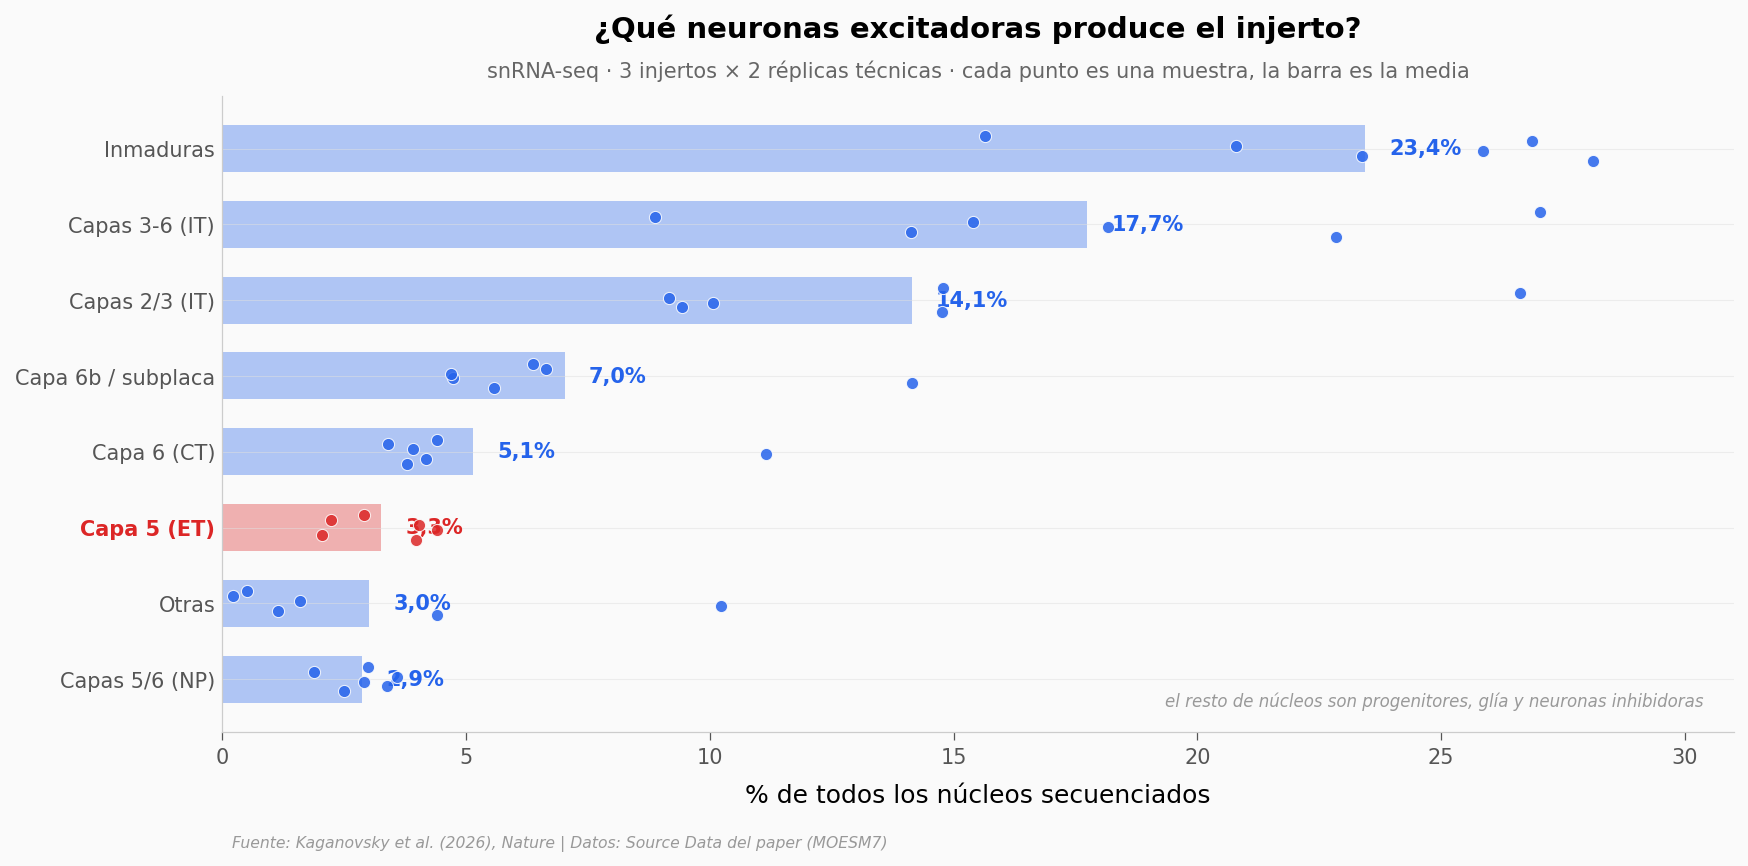

Neuronas L5-ET: 3,26% ± 0,41 SEM de los núcleos (6 muestras, rango 2,04–4,40%)
Los 8 clusters excitadores suman 73–82% de los núcleos por muestra (media de las 2 réplicas)


In [3]:
NOMBRE = {'GluN_Immature': 'Inmaduras', 'GluN_L3-6-IT': 'Capas 3-6 (IT)', 'GluN_L2/3-IT': 'Capas 2/3 (IT)',
          'GluN_L6b/SP': 'Capa 6b / subplaca', 'GluN_L6-CT': 'Capa 6 (CT)', 'GluN_L5-ET': 'Capa 5 (ET)',
          'GluN_other': 'Otras', 'GluN_L5/6-NP': 'Capas 5/6 (NP)'}
media_clu = clu.groupby('cluster').pct_nucleos.mean().sort_values()
orden = list(media_clu.index)
np.random.seed(42)
fig, ax = plt.subplots(figsize=(13, 5.5))
for i, c in enumerate(orden):
    col = COLOR_ALERTA if c == 'GluN_L5-ET' else COLOR_DATOS
    ax.barh(i, media_clu[c], color=col, alpha=0.35, height=0.62)
    v = clu[clu.cluster == c].pct_nucleos.values
    y = np.linspace(i - 0.16, i + 0.16, len(v)); np.random.shuffle(y)
    ax.scatter(v, y, color=col, s=34, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=5)
    ax.text(media_clu[c] + 0.5, i, f'{es(media_clu[c], 1)}%', va='center', fontsize=10, fontweight='bold', color=col)
ax.set_yticks(range(len(orden)))
ax.set_yticklabels([NOMBRE[c] for c in orden], fontsize=10)
ax.get_yticklabels()[orden.index('GluN_L5-ET')].set_color(COLOR_ALERTA)
ax.get_yticklabels()[orden.index('GluN_L5-ET')].set_fontweight('bold')
ax.set_xlabel('% de todos los núcleos secuenciados')
ax.set_xlim(0, 31)
ax.set_title('¿Qué neuronas excitadoras produce el injerto?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'snRNA-seq · 3 injertos × 2 réplicas técnicas · cada punto es una muestra, la barra es la media',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.04, 'el resto de núcleos son progenitores, glía y neuronas inhibidoras',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='right', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/composicion_snrnaseq.png', dpi=200, bbox_inches='tight')
plt.show()

l5 = clu[clu.cluster == 'GluN_L5-ET'].pct_nucleos
print(f'Neuronas L5-ET: {es(l5.mean(), 2)}% ± {es(l5.std(ddof=1)/np.sqrt(len(l5)), 2)} SEM de los núcleos '
      f'({len(l5)} muestras, rango {es(l5.min(), 2)}–{es(l5.max(), 2)}%)')
suma = clu.groupby('muestra_id').pct_nucleos.sum()
print(f'Los 8 clusters excitadores suman {es(suma.min()/2, 0)}–{es(suma.max()/2, 0)}% de los núcleos por muestra (media de las 2 réplicas)')

Casi una de cada cuatro células es una neurona excitadora todavía inmadura, y las maduras se reparten entre capas: las de capas 3-6 y 2/3 dominan. Las L5-ET del abstract están, pero son pocas: las neuronas L5-ET son el 3,26% de los núcleos en snRNA-seq, y las seis muestras coinciden (rango 2,0–4,4%). Un injerto que produce el tipo de neurona que proyecta hacia fuera del córtex es lo que hace pensar en conexión con el resto del sistema nervioso — el paper lo enmarca como "diversidad de tipos celulares corticales humanos, incluidas neuronas de proyección extratelencefálicas de capa 5". Son el 3%, no la mayoría.

## ¿Y cómo se mueve un ratón así?

Aquí está la parte que más sorprende. Un ratón sin neuronas excitadoras en el córtex debería moverse fatal. Le pusieron a caminar por una pasarela con cámara (*CatWalk*) y midieron velocidad, qué patas apoya en cada momento y el orden en que las mueve.

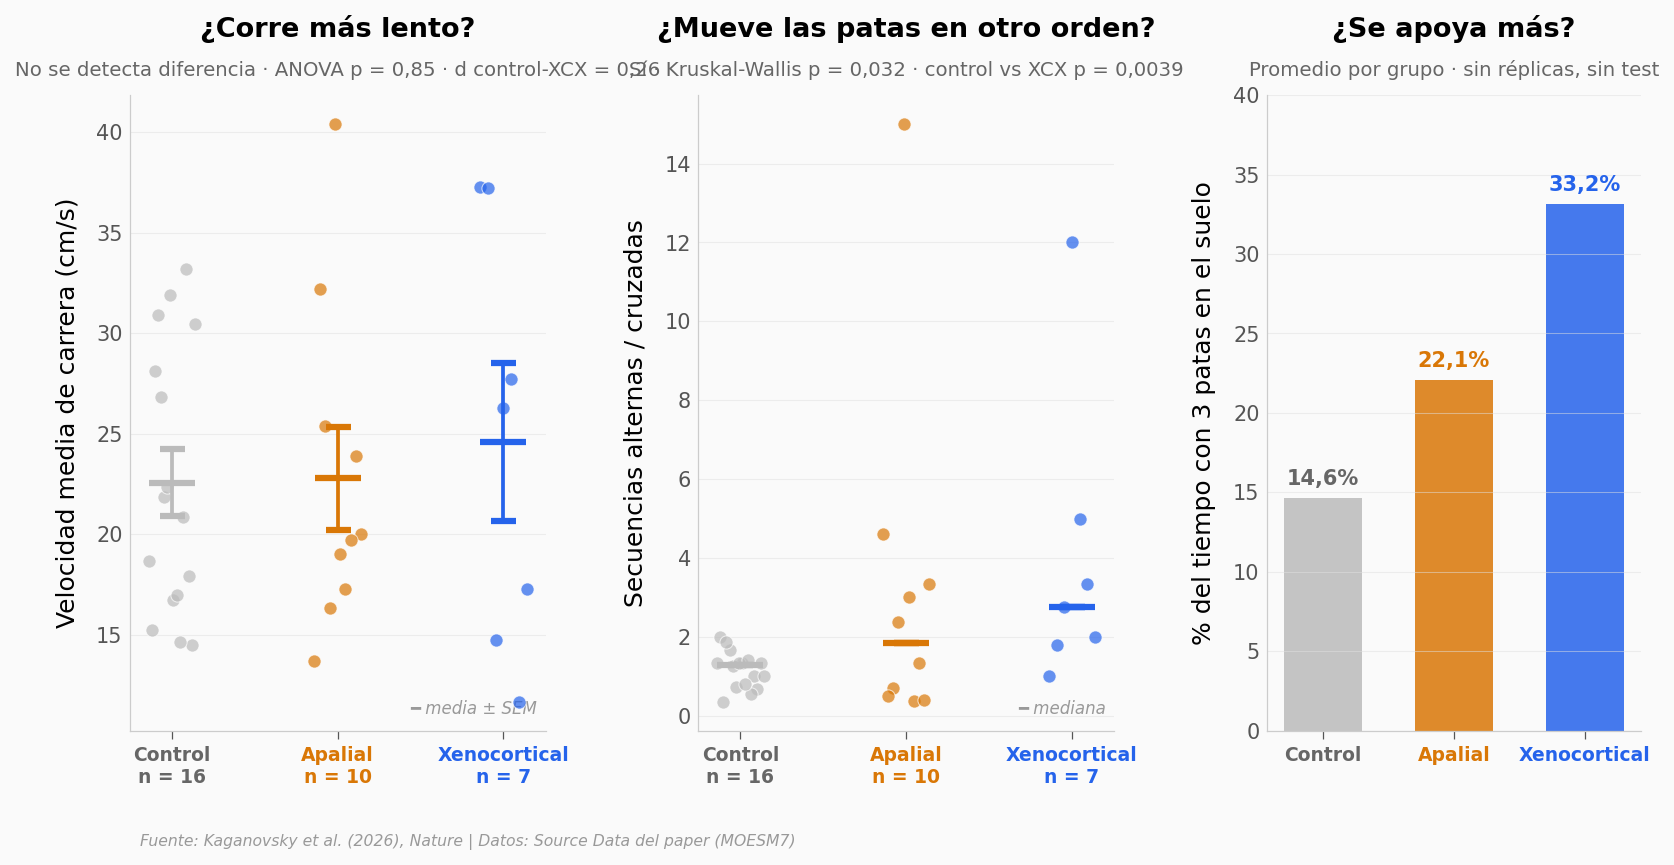

Velocidad Control      : 22,6 ± 6,7 cm/s (n = 16)
Velocidad Apalial      : 22,8 ± 8,1 cm/s (n = 10)
Velocidad Xenocortical : 24,6 ± 10,4 cm/s (n = 7)
ANOVA p = 0,847 · Kruskal-Wallis p = 0,966 · d control vs XCX = 0,26
Ratio alterno/cruzado Control      : mediana 1,29 (IQR 0,78–1,35, n = 16)
Ratio alterno/cruzado Apalial      : mediana 1,85 (IQR 0,55–3,25, n = 10)
Ratio alterno/cruzado Xenocortical : mediana 2,75 (IQR 1,90–4,17, n = 7)
Kruskal-Wallis p = 0,032 · Mann-Whitney control vs XCX p = 0,0039 · d = 1,38
3 patas en el suelo: XCX / control = 2,27× (nivel de grupo, sin test posible)


In [4]:
np.random.seed(42)
POS = [0, 1, 2]

def strip(ax, df, col, marcador='media', ylabel=''):
    for i, g in enumerate(GRUPOS):
        v = df[df.grupo == g][col].dropna().values
        x = np.linspace(POS[i] - 0.14, POS[i] + 0.14, len(v)); np.random.shuffle(x)
        ax.scatter(x, v, color=COL_GRUPO[g], s=40, alpha=0.7, edgecolors='white', linewidths=0.5, zorder=5)
        if marcador == 'media':
            m, err = v.mean(), v.std(ddof=1) / np.sqrt(len(v))
        else:
            m, err = np.median(v), 0
        ax.errorbar(POS[i], m, yerr=err, fmt='_', color=COL_GRUPO[g], markersize=22, markeredgewidth=3,
                    capsize=6, capthick=1.5, zorder=6)
    ax.set_xticks(POS)
    ax.set_xticklabels([f'{ETIQ[g]}\nn = {len(df[df.grupo == g])}' for g in GRUPOS], fontsize=9, fontweight='bold')
    for tick, g in zip(ax.get_xticklabels(), GRUPOS):
        tick.set_color(COL_GRUPO[g] if g != 'Control' else '#666666')
    ax.set_ylabel(ylabel)

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1, 1, 0.9]})

# 1. Velocidad (preservada)
strip(a1, vel, 'velocidad_cm_s', 'media', 'Velocidad media de carrera (cm/s)')
f_a, p_a = stats.f_oneway(*[vel[vel.grupo == g].velocidad_cm_s for g in GRUPOS])
h_k, p_k = stats.kruskal(*[vel[vel.grupo == g].velocidad_cm_s for g in GRUPOS])
d_vel = cohen_d(vel[vel.grupo == 'XCX'].velocidad_cm_s, vel[vel.grupo == 'Control'].velocidad_cm_s)
a1.set_title('¿Corre más lento?', fontsize=13, fontweight='bold', pad=28)
a1.text(0.5, 1.03, f'No se detecta diferencia · ANOVA p = {es(p_a, 2)} · d control-XCX = {es(d_vel, 2)}',
        transform=a1.transAxes, fontsize=9.5, color='#666666', ha='center')
a1.text(0.98, 0.02, '━ media ± SEM', transform=a1.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

# 2. Ratio de secuencias alternas / cruzadas (alterada)
strip(a2, rat, 'ratio_alterno_cruzado', 'mediana', 'Secuencias alternas / cruzadas')
h_r, p_kr = stats.kruskal(*[rat[rat.grupo == g].ratio_alterno_cruzado for g in GRUPOS])
u_r, p_mw = stats.mannwhitneyu(rat[rat.grupo == 'XCX'].ratio_alterno_cruzado,
                              rat[rat.grupo == 'Control'].ratio_alterno_cruzado, alternative='two-sided')
d_rat = cohen_d(rat[rat.grupo == 'XCX'].ratio_alterno_cruzado, rat[rat.grupo == 'Control'].ratio_alterno_cruzado)
a2.set_title('¿Mueve las patas en otro orden?', fontsize=13, fontweight='bold', pad=28)
a2.text(0.5, 1.03, f'Sí · Kruskal-Wallis p = {es(p_kr, 3)} · control vs XCX p = {es(p_mw, 4)}',
        transform=a2.transAxes, fontsize=9.5, color='#666666', ha='center')
a2.text(0.98, 0.02, '━ mediana', transform=a2.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

# 3. % del tiempo con 3 patas en el suelo (nivel de grupo, sin replicas)
tres = pat[pat.patron_apoyo == 'Three'].set_index('grupo').pct_tiempo
bars = a3.bar(POS, [tres[g] for g in GRUPOS], color=[COL_GRUPO[g] for g in GRUPOS], width=0.6, alpha=0.85)
for i, g in enumerate(GRUPOS):
    a3.text(POS[i], tres[g] + 0.8, f'{es(tres[g], 1)}%', ha='center', fontsize=10, fontweight='bold', color=COL_GRUPO[g] if g != 'Control' else '#666666')
a3.set_xticks(POS); a3.set_xticklabels([ETIQ[g] for g in GRUPOS], fontsize=9, fontweight='bold')
for tick, g in zip(a3.get_xticklabels(), GRUPOS):
    tick.set_color(COL_GRUPO[g] if g != 'Control' else '#666666')
a3.set_ylim(0, 40)
a3.set_ylabel('% del tiempo con 3 patas en el suelo')
a3.set_title('¿Se apoya más?', fontsize=13, fontweight='bold', pad=28)
a3.text(0.5, 1.03, 'Promedio por grupo · sin réplicas, sin test', transform=a3.transAxes, fontsize=9.5, color='#666666', ha='center')

fig.subplots_adjust(wspace=0.38)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/conducta_catwalk.png', dpi=200, bbox_inches='tight')
plt.show()

for g in GRUPOS:
    v = vel[vel.grupo == g].velocidad_cm_s
    print(f'Velocidad {ETIQ[g]:13s}: {es(v.mean(), 1)} ± {es(v.std(ddof=1), 1)} cm/s (n = {len(v)})')
print(f'ANOVA p = {es(p_a, 3)} · Kruskal-Wallis p = {es(p_k, 3)} · d control vs XCX = {es(d_vel, 2)}')
for g in GRUPOS:
    v = rat[rat.grupo == g].ratio_alterno_cruzado
    print(f'Ratio alterno/cruzado {ETIQ[g]:13s}: mediana {es(v.median(), 2)} (IQR {es(v.quantile(.25), 2)}–{es(v.quantile(.75), 2)}, n = {len(v)})')
print(f'Kruskal-Wallis p = {es(p_kr, 3)} · Mann-Whitney control vs XCX p = {es(p_mw, 4)} · d = {es(d_rat, 2)}')
print(f'3 patas en el suelo: XCX / control = {es(tres["XCX"]/tres["Control"], 2)}× (nivel de grupo, sin test posible)')

Velocidad: nada. Los tres grupos corren igual de rápido — o, para ser exactos, no se detecta diferencia (p = 0,85, y el tamaño de efecto entre control y xenocortical es pequeño, d = 0,26, con solo 7 ratones XCX). La locomoción básica no depende del córtex; la lleva el tronco encefálico y la médula.

Pero el *cómo* sí cambia. Los ratones xenocorticales encadenan más secuencias de paso alternas que cruzadas (ratio alterno/cruzado: nuestro Mann-Whitney sin corregir da p = 0,0039 para control vs xenocortical; el post-hoc corregido del paper para esa misma comparación da p = 0,041 — ambos por debajo de 0,05) y pasan más del doble de tiempo con tres patas apoyadas a la vez: 33,2% frente al 14,6% del control. Ese último dato viene a nivel de grupo — el archivo trae un promedio por grupo, sin los ratones individuales — así que no podemos ponerle una p. Es la "diferencia selectiva en la coordinación de las extremidades" que menciona el paper: caminan, pero con otra estrategia de apoyo.

## ¿Y la memoria?

Última prueba: un laberinto con tres brazos en forma de Y. Un ratón normal tiende a entrar en el brazo que no acaba de visitar — la alternancia espontánea. Si eligiera al azar, alternaría el 50% de las veces.

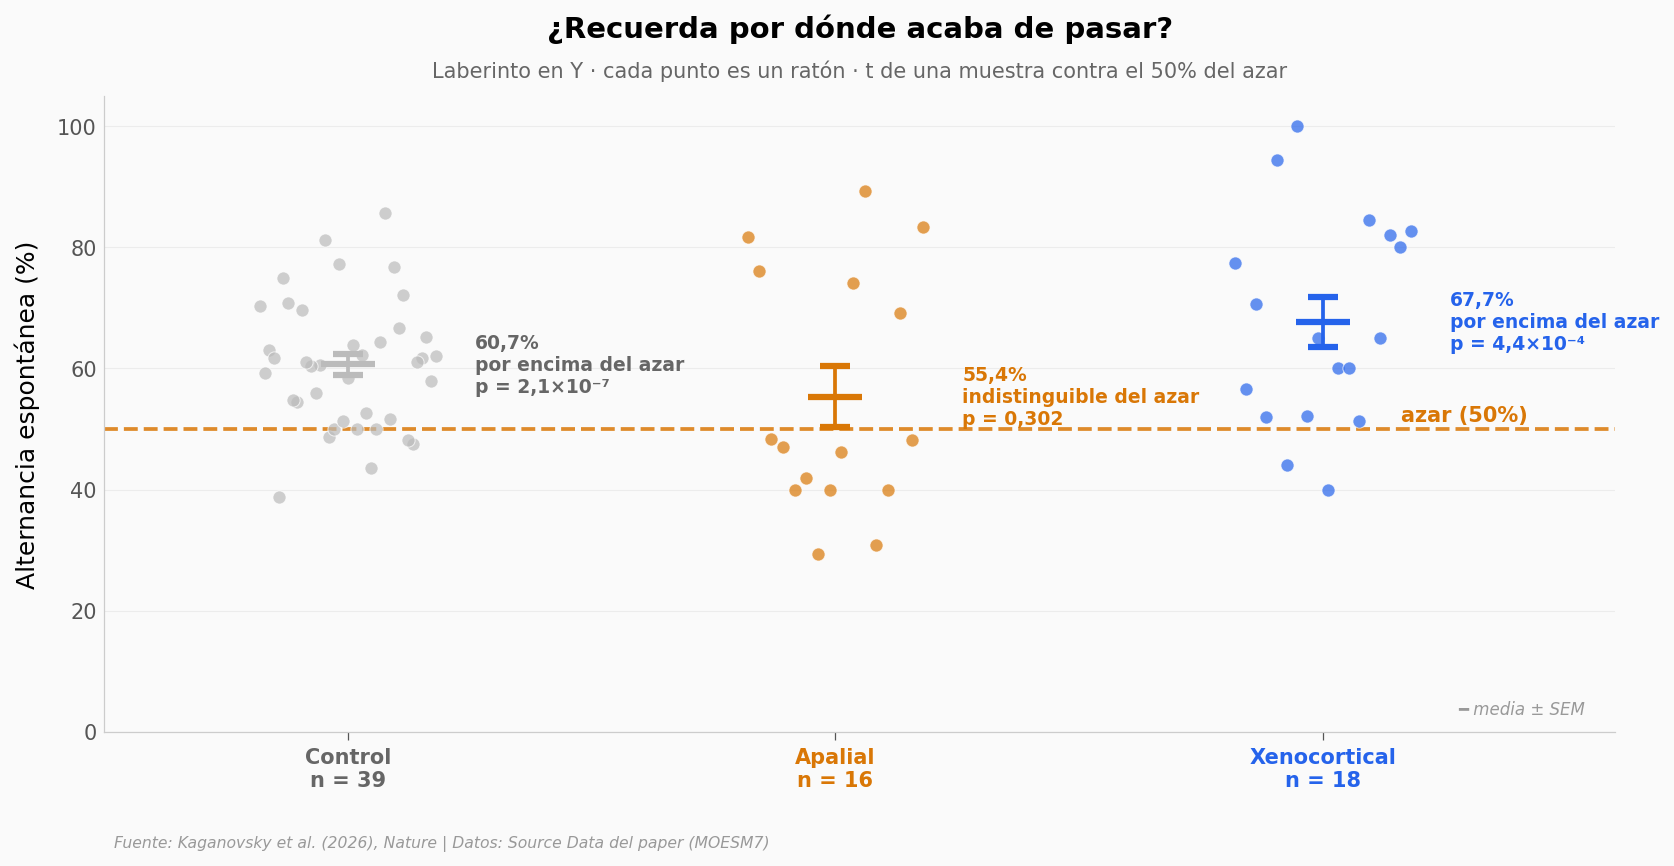

Control      : 60,7 ± 10,5% (n = 39) · t = 6,32 · p = 2,1×10⁻⁷
Apalial      : 55,4 ± 20,1% (n = 16) · t = 1,07 · p = 0,302
Xenocortical : 67,7 ± 17,3% (n = 18) · t = 4,34 · p = 4,4×10⁻⁴
Distancia recorrida (cm): Control 1.466 ± 383 · Apalial 1.213 ± 439 · Xenocortical 1.337 ± 485 · ANOVA (log) p = 0,075


In [5]:
np.random.seed(42)
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axhline(AZAR_YMAZE, color=COLOR_REFERENCIA, linewidth=1.8, linestyle='--', alpha=0.85, zorder=2)
ax.text(2.42, AZAR_YMAZE + 1.2, f'azar ({AZAR_YMAZE}%)', fontsize=10, fontweight='bold', color=COLOR_REFERENCIA, ha='right')
res_ym = {}
for i, g in enumerate(GRUPOS):
    v = ym[ym.grupo == g].alternancia_pct.dropna().values
    t1, p1 = stats.ttest_1samp(v, AZAR_YMAZE)
    res_ym[g] = (v.mean(), v.std(ddof=1), len(v), t1, p1)
    x = np.linspace(POS[i] - 0.18, POS[i] + 0.18, len(v)); np.random.shuffle(x)
    ax.scatter(x, v, color=COL_GRUPO[g], s=40, alpha=0.7, edgecolors='white', linewidths=0.5, zorder=5)
    ax.errorbar(POS[i], v.mean(), yerr=v.std(ddof=1)/np.sqrt(len(v)), fmt='_', color=COL_GRUPO[g],
                markersize=26, markeredgewidth=3, capsize=7, capthick=1.5, zorder=6)
    veredicto = 'por encima del azar' if p1 < 0.05 else 'indistinguible del azar'
    ax.text(POS[i] + 0.26, v.mean(), f'{es(v.mean(), 1)}%\n{veredicto}\np = {sci(p1)}', fontsize=9,
            color=COL_GRUPO[g] if g != 'Control' else '#666666', va='center', fontweight='bold')
ax.set_xticks(POS)
ax.set_xticklabels([f'{ETIQ[g]}\nn = {res_ym[g][2]}' for g in GRUPOS], fontsize=10, fontweight='bold')
for tick, g in zip(ax.get_xticklabels(), GRUPOS):
    tick.set_color(COL_GRUPO[g] if g != 'Control' else '#666666')
ax.set_xlim(-0.5, 2.6)
ax.set_ylim(0, 105)
ax.set_ylabel('Alternancia espontánea (%)')
ax.set_title('¿Recuerda por dónde acaba de pasar?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Laberinto en Y · cada punto es un ratón · t de una muestra contra el 50% del azar',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ymaze_alternancia.png', dpi=200, bbox_inches='tight')
plt.show()

for g in GRUPOS:
    m, sd, n_g, t1, p1 = res_ym[g]
    print(f'{ETIQ[g]:13s}: {es(m, 1)} ± {es(sd, 1)}% (n = {n_g}) · t = {es(t1, 2)} · p = {sci(p1)}')
f_d, p_d = stats.f_oneway(*[np.log(ym[ym.grupo == g].distancia_cm.dropna()) for g in GRUPOS])
print(f'Distancia recorrida (cm): ' + ' · '.join(f'{ETIQ[g]} {es(ym[ym.grupo == g].distancia_cm.mean())} ± {es(ym[ym.grupo == g].distancia_cm.std(ddof=1))}' for g in GRUPOS) + f' · ANOVA (log) p = {es(p_d, 3)}')

El grupo control alterna el 60,7% de las veces, claramente por encima del azar. Los ratones apaliales — sin córtex ni hipocampo funcionales — caen al 55,4% y, con la dispersión que tienen, no se distinguen de tirar una moneda (alternancia en el Y-maze: apaliales 55,4% (p = 0,30 contra el azar), xenocorticales 67,7% (p = 0,0004)). Los xenocorticales, con el córtex de células humanas, vuelven a alternar por encima del azar. Ojo: esto no dice que "recuperaron la memoria" — el paper lo enmarca como una *organización alterada del comportamiento espontáneo*, y los tres grupos recorren distancias parecidas (p = 0,075), así que no es cuestión de moverse más o menos. Es un dato de comportamiento, no una prueba de función cognitiva humana en un ratón.

## ¿Qué tan humanas son estas neuronas?

Una última pieza. En el córtex humano hay un tipo de neurona grande y alargada, las neuronas de von Economo (VEN), que en roedores prácticamente no existe. El equipo encontró en los injertos células con esa morfología y midió el diámetro de su cuerpo celular (soma) en 1.098 de ellas.

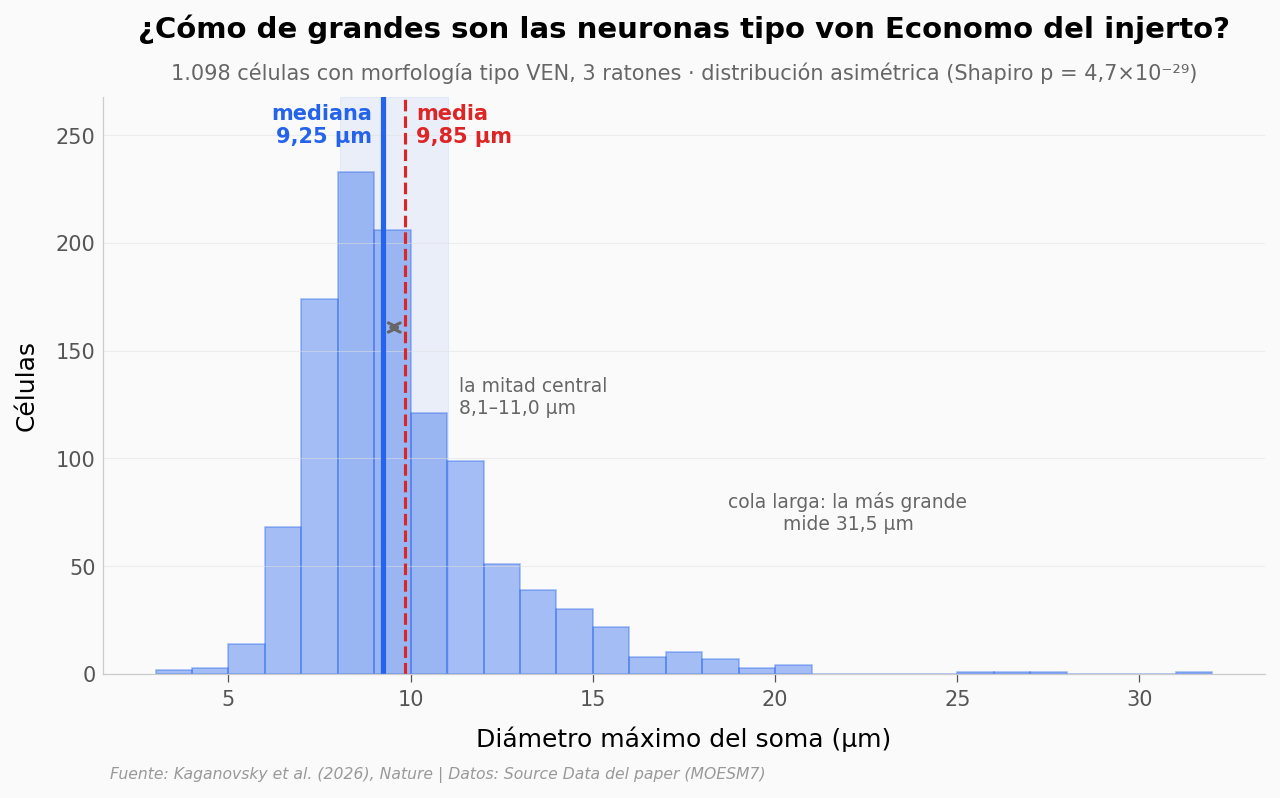

n = 1.098 · media 9,85 µm · mediana 9,25 µm · IQR 8,06–11,04 · rango 3,3–31,5 µm
Asimetría (skew) = 1,91 · Shapiro-Wilk p = 4,7×10⁻²⁹ → no es normal: usar mediana, no media


In [6]:
d_s = som.diametro_soma_um.dropna()
media, mediana = d_s.mean(), d_s.median()
q1, q3 = d_s.quantile(0.25), d_s.quantile(0.75)
sh_w, sh_p = stats.shapiro(d_s)

fig, ax = plt.subplots(figsize=(10, 5))
n_h, bins, patches = ax.hist(d_s, bins=np.arange(3, 32.5, 1), color=COLOR_DATOS, alpha=0.4,
                             edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n_h.max() * 1.15
ax.set_ylim(0, y_max)
ax.axvline(mediana, color=COLOR_DATOS, linewidth=2.5)
ax.axvline(media, color=COLOR_ALERTA, linewidth=1.5, linestyle='--')
ax.annotate('', xy=(media, y_max*0.6), xytext=(mediana, y_max*0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(mediana - 0.3, y_max*0.92, f'mediana\n{es(mediana, 2)} µm', fontsize=10, fontweight='bold', color=COLOR_DATOS, ha='right')
ax.text(media + 0.3, y_max*0.92, f'media\n{es(media, 2)} µm', fontsize=10, fontweight='bold', color=COLOR_ALERTA)
ax.axvspan(q1, q3, color=COLOR_DATOS, alpha=0.08, zorder=0)
ax.text(q3 + 0.3, y_max*0.45, f'la mitad central\n{es(q1, 1)}–{es(q3, 1)} µm', fontsize=9, color='#666666')
ax.text(22, y_max*0.25, f'cola larga: la más grande\nmide {es(d_s.max(), 1)} µm', fontsize=9, color='#666666', ha='center')
ax.set_xlabel('Diámetro máximo del soma (µm)')
ax.set_ylabel('Células')
ax.set_title('¿Cómo de grandes son las neuronas tipo von Economo del injerto?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{es(len(d_s))} células con morfología tipo VEN, 3 ratones · distribución asimétrica (Shapiro p = {sci(sh_p)})',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/soma_ven.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'n = {es(len(d_s))} · media {es(media, 2)} µm · mediana {es(mediana, 2)} µm · IQR {es(q1, 2)}–{es(q3, 2)} · rango {es(d_s.min(), 1)}–{es(d_s.max(), 1)} µm')
print(f'Asimetría (skew) = {es(stats.skew(d_s), 2)} · Shapiro-Wilk p = {sci(sh_p)} → no es normal: usar mediana, no media')

Las células están concentradas alrededor de 9 µm, con una cola larga hacia la derecha — diámetro de soma tipo VEN: mediana 9,25 µm (n = 1.098). Por eso la media (9,85 µm) queda a la derecha de la mediana: unas pocas células muy grandes tiran de ella. Lo honesto es citar la mediana. Y una cautela: *morfología tipo VEN* no es lo mismo que *neurona de von Economo confirmada*; el paper habla de células con esa forma, y nosotros también.

Y una cosa que quisimos hacer y no pudimos. El paper deposita en Zenodo un mapa espacial del injerto (MERFISH) con más de 100.000 células segmentadas y su tipo celular. Lo descargamos, lo dibujamos, y los tipos celulares salían en bloques rectangulares perfectos: en el archivo, la anotación de tipo está pegada por un identificador que colapsa unas 228 células en cada valor (452 identificadores distintos para 103.097 células), así que la etiqueta es por bloque, no por célula. No sirve para un mapa ni para contar tipos, y lo dejamos fuera. La composición celular de arriba sale de la secuenciación de núcleos, que sí es por célula.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El injerto humano crece ~4,7× entre los 2 y los 3 meses | ✅ | 14 de 14 ratones crecieron; t pareado = 8,22, p = 1,7×10⁻⁶, d pareado = 2,20. El 4,7× es la media de los ratios por ratón; la mediana es 3,77× (rango 2,6–8,9×) |
| A los 3 meses casi todo el córtex (91,9%) es de origen humano | ✅ | 91,9% ± 2,7, n = 7, rango 88,6–96,2%. Coincide con el paper al decimal |
| El injerto genera neuronas de proyección de capa 5 (L5-ET) | ✅ | snRNA-seq: 3,26% ± 0,41 SEM de los núcleos, presentes en las 6 muestras (rango 2,0–4,4%). Son una minoría; el paper habla de "diversidad", no de abundancia |
| La locomoción se conserva en términos generales | ⚠️ | Velocidad CatWalk: ANOVA p = 0,85, d control-XCX = 0,26. Es "sin diferencia detectable" con n = 16/10/7, no igualdad demostrada. La distancia en el Y-maze tampoco difiere (p = 0,075) |
| Hay diferencias selectivas en la coordinación de las extremidades | ✅ | Ratio alterno/cruzado: Kruskal-Wallis p = 0,032, Mann-Whitney control vs XCX p = 0,0039. El % con 3 patas apoyadas (33,2 vs 14,6%) es un promedio por grupo sin réplicas: ilustra, no prueba |
| Los ratones apaliales no superan el azar en el Y-maze; los xenocorticales sí | ✅ | t de una muestra contra 50%: control p = 2×10⁻⁷, apalial p = 0,30, xenocortical p = 0,0004. El paper lo enmarca como *organización alterada del comportamiento espontáneo*, no como memoria recuperada |

> **Limitaciones:** (1) El % de tiempo por patrón de apoyo (3 patas, diagonal, una pata) viene a nivel de grupo, sin ratones individuales — no admite test ni tamaño de efecto. (2) Las neuronas L5-ET se cuantifican solo por snRNA-seq (3 injertos, 2 líneas celulares); no tenemos su posición en el tejido. (3) El mapa espacial MERFISH de Zenodo (muestra XCX_d168_1208-2) tiene la anotación de tipo celular colapsada por bloques de ~228 células, así que no lo usamos — ni para el mapa ni para contar tipos. (4) En el Y-maze, distancia y alternancia se emparejaron por orden de fila dentro de cada grupo; sirve para estadística por grupo, no para correlaciones por ratón. (5) La n de conducta está desbalanceada (16/10/7 en CatWalk): "preservada" significa que no se detecta diferencia, no que sean iguales. (6) En snRNA-seq los % son sobre el total de núcleos; los 8 clusters excitadores suman 73–82% por muestra, el resto son progenitores, glía y GABA.

## Ahora tú

1. **¿El ratio de crecimiento depende del tamaño inicial?** Los injertos pequeños a los 2 meses, ¿crecen proporcionalmente más? Prueba `stats.spearmanr(cre.vol_2_meses_mm3, cre.ratio)` y dibuja el scatter. Con n = 14, ¿qué tan lejos estás de poder afirmar algo?

2. **¿Las dos líneas celulares producen el mismo córtex?** En `clu` hay dos líneas (`linea_hips`). Compara el % de neuronas inmaduras y de L5-ET entre ellas (`clu.groupby(['linea_hips', 'cluster']).pct_nucleos.mean().unstack()`). ¿Qué diferencia te parecería relevante con 1 y 2 injertos por línea?

3. **¿Cuánto cambia la alternancia si mueves la línea del azar?** El 50% supone tres brazos y elección uniforme. Cambia `AZAR_YMAZE` a `45` o `55` en la configuración y vuelve a ejecutar la celda del laberinto. ¿Qué grupo cambia de veredicto primero, y qué te dice eso de la robustez del resultado?

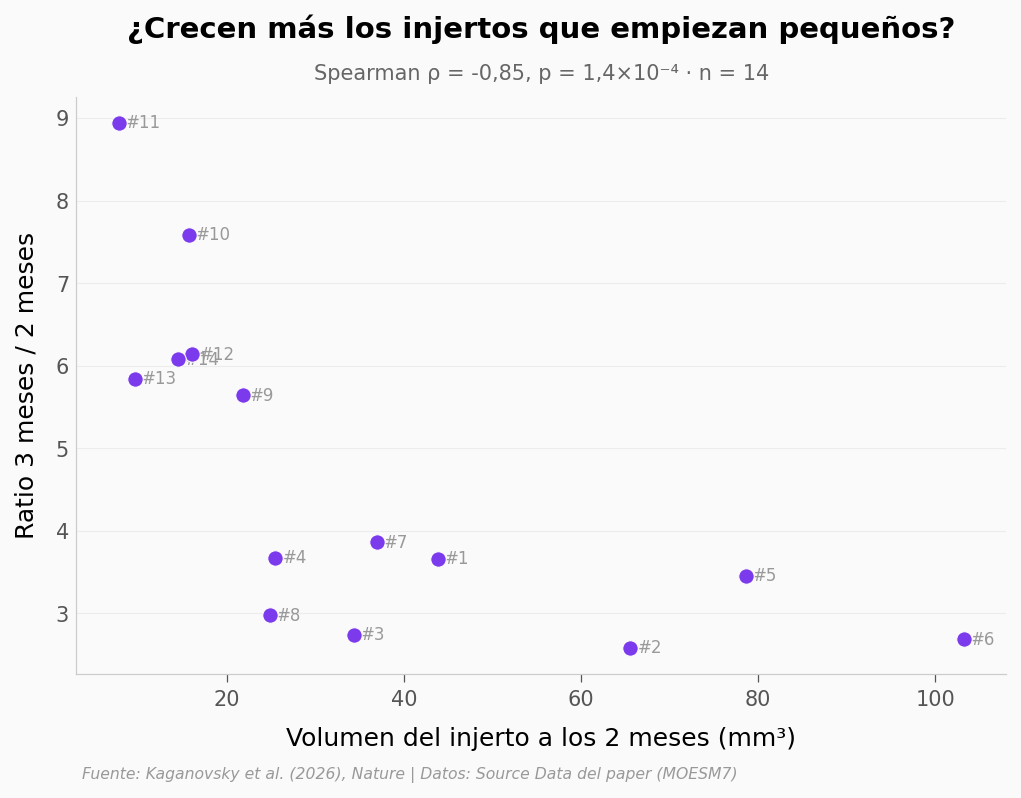

Spearman ρ = -0,85, p = 1,4×10⁻⁴: los injertos que empiezan pequeños multiplican más su volumen.
Ojo: el volumen inicial está en el denominador del ratio, así que parte de esa correlación es aritmética (regresión a la media).
Para separarlo, prueba a correlacionar el volumen a los 2 meses con el volumen a los 3 (no con el ratio).


In [7]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿los injertos pequeños a los 2 meses crecen proporcionalmente más?
rho, p_rho = stats.spearmanr(cre.vol_2_meses_mm3, cre.ratio)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(cre.vol_2_meses_mm3, cre.ratio, color=COLOR_CORRELACION, s=55, edgecolors='white', linewidths=0.5, zorder=5)
for _, r in cre.iterrows():
    ax.text(r.vol_2_meses_mm3 + 0.8, r.ratio, f'#{int(r.raton_id)}', fontsize=8, color='#999999', va='center')
ax.set_xlabel('Volumen del injerto a los 2 meses (mm³)')
ax.set_ylabel('Ratio 3 meses / 2 meses')
ax.set_title('¿Crecen más los injertos que empiezan pequeños?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Spearman ρ = {es(rho, 2)}, p = {sci(p_rho)} · n = {len(cre)}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/experimento_tamano_inicial.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Spearman ρ = {es(rho, 2)}, p = {sci(p_rho)}: los injertos que empiezan pequeños multiplican más su volumen.')
print('Ojo: el volumen inicial está en el denominador del ratio, así que parte de esa correlación es aritmética (regresión a la media).')
print('Para separarlo, prueba a correlacionar el volumen a los 2 meses con el volumen a los 3 (no con el ratio).')

## Créditos

- **Paper:** Kaganovsky, K. et al. (2026). *Developmental xenocortication using human-derived organoids in mice*. Nature. DOI: [10.1038/s41586-026-11032-2](https://doi.org/10.1038/s41586-026-11032-2). Open Access.
- **Datos:** Source Data de las Figs. 1, 2 y 4 y Extended Data Fig. 7 del paper (MOESM7), convertidos a CSV. El depósito MERFISH de [Zenodo 21138437](https://doi.org/10.5281/zenodo.21138437) se descargó pero no se usa (anotación de tipo celular colapsada por bloques; ver limitaciones).
- **Código:** [Ciencia a Mordiscos / lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-09-16-xenocortex-organoides-humanos-raton) — MIT.

## Fuentes

**Paper**: [Developmental xenocortication using human-derived organoids in mice](https://doi.org/10.1038/s41586-026-11032-2)  
*Nature, 2026-09-16*

**Supplementary Material**: [Source Data Figs. 1–5 and Extended Data Figs. 1, 3, 5–10 for "Developmental xenocortication using human-derived organoids in mice" (MOESM7)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-11032-2/MediaObjects/41586_2026_11032_MOESM7_ESM.zip)  
*Nature, 2026-09-16*

*17 afirmaciones del notebook verificadas contra estas fuentes*